# Fig. 3 — Scatter plot with error bars: predictions vs. ground truth

This notebook demonstrates a scatter plot with error bars comparing two methods.

Key points:
- Loading data from a YAML summary file
- Drawing a diagonal reference line ("perfect prediction" guide for the eye)
- Using `ax.errorbar()` with caps for clean error bars
- Slightly offsetting two methods horizontally to avoid overlap
- How a guide line immediately communicates meaning without a caption

In [1]:
import yaml
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from cb_colors import palettes

# ── Version switch ────────────────────────────────────────────────────────────
VERSION = "paper"   # "paper" | "slides" | "dark"

# ── Load style ────────────────────────────────────────────────────────────────
matplotlib.rc_file("../../../matplotlibrc_ml")

# ── Figure size ───────────────────────────────────────────────────────────────
# Square scatter plots: equal aspect ratio, so width = height
TEXTWIDTH = 5.5

if VERSION == "paper":
    FIGWIDTH  = TEXTWIDTH * 0.48
    FONT_SIZE = 7.5
    SUFFIX    = ""
    TRANSPARENT = True
elif VERSION == "slides":
    FIGWIDTH  = 4.0
    FONT_SIZE = 13.0
    SUFFIX    = "_slides"
    TRANSPARENT = False
elif VERSION == "dark":
    FIGWIDTH  = 4.0
    FONT_SIZE = 13.0
    SUFFIX    = "_dark"
    TRANSPARENT = True

matplotlib.rcParams.update({"font.size": FONT_SIZE})

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
with open("../data/example_data.yaml") as f:
    data = yaml.safe_load(f)

axis_range = data["axis_range"]

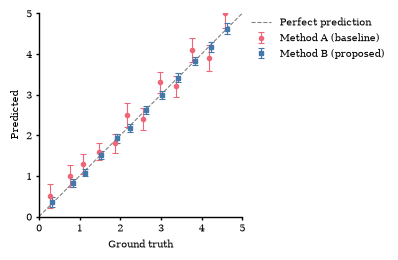

In [3]:
# ── Colors ────────────────────────────────────────────────────────────────────
# paul_tol_bright: clean, vivid colors with good contrast for scatter points
c = palettes.paul_tol_bright()

METHODS = [
    ("method_a", c["red"],     "o", -0.03),  # (key, color, marker, x-offset)
    ("method_b", c["blue"],     "s",  0.03),
]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIGWIDTH, FIGWIDTH))  # square

# Diagonal reference line: perfect prediction
ax.plot(axis_range, axis_range, color="gray", linewidth=0.8, linestyle="--", zorder=0,
        label="Perfect prediction")

for key, color, marker, dx in METHODS:
    d = data[key]
    x     = np.array(d["x"]) + dx  # small horizontal offset to avoid overlap
    y     = np.array(d["y"])
    y_err = np.array(d["y_err"])

    ax.errorbar(
        x, y, yerr=y_err,
        fmt=marker, color=color, label=d["label"],
        markersize=3, linewidth=0.8, capsize=2, capthick=0.8,
        ecolor=color, elinewidth=0.8,
    )

ax.set_xlim(axis_range)
ax.set_ylim(axis_range)
ax.set_xlabel(data["x_label"])
ax.set_ylabel(data["y_label"])
ax.set_aspect("equal")

# Legend slightly outside the axes bbox — avoids overlap with diagonal and data
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

if VERSION == "dark":
    BG = "#1c1c2e"
    FG = "white"
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.tick_params(colors=FG)
    ax.xaxis.label.set_color(FG)
    ax.yaxis.label.set_color(FG)
    for spine in ax.spines.values():
        spine.set_edgecolor(FG)

plt.show()


In [4]:
# ── Save ──────────────────────────────────────────────────────────────────────
out_path = f"../pdf/fig_03{SUFFIX}.pdf"
fig.savefig(out_path, transparent=TRANSPARENT)
print(f"Saved: {out_path}")

# Save preview PNG for README
if VERSION == "paper":
    fig.savefig("../png/fig_03_preview.png", dpi=150, bbox_inches="tight", facecolor="white", transparent=False)
    print("Saved preview PNG")


Saved: ../pdf/fig_03.pdf
Saved preview PNG
